<a href="https://colab.research.google.com/github/DivyaSwamy/transformers_tutorials/blob/main/FineTuning_ObjectDetction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### WIP - Following tutorial to learn about fine tuning a preexisting model.

https://huggingface.co/learn/cookbook/en/fine_tuning_detr_custom_dataset


What happens if you train with and without albumentations ?

#### Install Dependencies

In [2]:
#!pip install -U -q datasets transformers[torch] timm wandb torchmetrics matplotlib albumentations


In [1]:
import io
from PIL import Image
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from huggingface_hub import notebook_login

from datasets import load_dataset, DatasetDict

from transformers import AutoImageProcessor, ViTForImageClassification

from transformers import Trainer, TrainingArguments


In [3]:
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('huggingface_token') # Retrieve the token from secrets

if HF_TOKEN:
  login(HF_TOKEN)
  print("Successfully logged in to Hugging Face!")
else:
  print("Hugging Face token not found in Colab Secrets.")

Successfully logged in to Hugging Face!


#### Load Fashionpedia dataset from Huggingface

* Take a subset of the dataset as it's a large dataset.



In [4]:
from datasets import load_dataset

dataset = load_dataset('detection-datasets/fashionpedia')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00007-fe108070118553(…):   0%|          | 0.00/482M [00:00<?, ?B/s]

data/train-00001-of-00007-f41a5a9c38c900(…):   0%|          | 0.00/480M [00:00<?, ?B/s]

...

data/train-00005-of-00007-41d8dfe1edb659(…):   0%|          | 0.00/487M [00:00<?, ?B/s]

data/train-00006-of-00007-f41b0f2f4bbefa(…):   0%|          | 0.00/487M [00:00<?, ?B/s]

data/val-00000-of-00001-0b29e85429788213(…):   0%|          | 0.00/84.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45623 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1158 [00:00<?, ? examples/s]

In [5]:
for elem in dataset:
  print( elem, ': Number of items in dataset:-', len(dataset[elem]))

train : Number of items in dataset:- 45623
val : Number of items in dataset:- 1158


In [6]:
def create_sample(dataset, fraction = 0.1, seed = 22):
  '''
  Function generates a subset from a given dataset.
  '''
  sample_size = int(fraction*len(dataset))
  sampled_dataset = dataset.shuffle(seed = seed).select(range(sample_size))

  return sampled_dataset

In [7]:
train_dataset = create_sample(dataset['train'], fraction = 0.05)
test_dataset = create_sample(dataset['val'], fraction = 0.1)

In [8]:
print(len(train_dataset), len(test_dataset))

2281 115


In [9]:
train_dataset

Dataset({
    features: ['image_id', 'image', 'width', 'height', 'objects'],
    num_rows: 2281
})

#### Explore dataset

* Generate ids2label and label2idx
* Explore some images to see what's in the dataset

In [10]:
idx = 250

print('Number of detections in image id', idx)
for elem in train_dataset[idx]['objects']:
  print(elem, len(train_dataset[idx]['objects'][elem]))

Number of detections in image id 250
bbox_id 2
category 2
bbox 2
area 2


In [12]:
#plt.imshow(train_dataset[idx]['image'])

In [13]:
import numpy as np
from PIL import Image, ImageDraw

# Put together the list of labels and ids - has to be done by hand

id2label = {
    0: 'shirt, blouse', 1: 'top, t-shirt, sweatshirt', 2: 'sweater', 3: 'cardigan',
    4: 'jacket', 5: 'vest', 6: 'pants', 7: 'shorts', 8: 'skirt', 9: 'coat',
    10: 'dress', 11: 'jumpsuit', 12: 'cape', 13: 'glasses', 14: 'hat',
    15: 'headband, head covering, hair accessory', 16: 'tie', 17: 'glove',
    18: 'watch', 19: 'belt', 20: 'leg warmer', 21: 'tights, stockings',
    22: 'sock', 23: 'shoe', 24: 'bag, wallet', 25: 'scarf', 26: 'umbrella',
    27: 'hood', 28: 'collar', 29: 'lapel', 30: 'epaulette', 31: 'sleeve',
    32: 'pocket', 33: 'neckline', 34: 'buckle', 35: 'zipper', 36: 'applique',
    37: 'bead', 38: 'bow', 39: 'flower', 40: 'fringe', 41: 'ribbon',
    42: 'rivet', 43: 'ruffle', 44: 'sequin', 45: 'tassel'
}


label2id = {v: k for k, v in id2label.items()}


In [14]:
def draw_image_from_idx(dataset, idx):
  '''
  Function takes in image id and returns an annotated image based on image labelling.
  '''

  sample = dataset[idx]
  image = sample['image']
  objects = sample['objects']
  draw = ImageDraw.Draw(image)
  width, height = sample["width"], sample["height"]

  num_objects = len(objects['bbox_id'])

  colors = [ 'red', 'green', 'blue', 'cyan', 'yellow', 'orange', 'pink', 'purple',
            'red', 'green', 'blue', 'cyan', 'yellow', 'orange', 'pink', 'purple',
             'red', 'green', 'blue', 'cyan', 'yellow', 'orange', 'pink', 'purple']

  for obj in range(num_objects):
    box = objects['bbox'][obj]
    x1, y1, x2, y2 = tuple(box)
    draw.rectangle((x1, y1, x2, y2), outline= colors[obj], width=3)
    draw.text((x1, y1), id2label[objects["category"][obj]], fill="white",
              fontsize = 16)

  return image





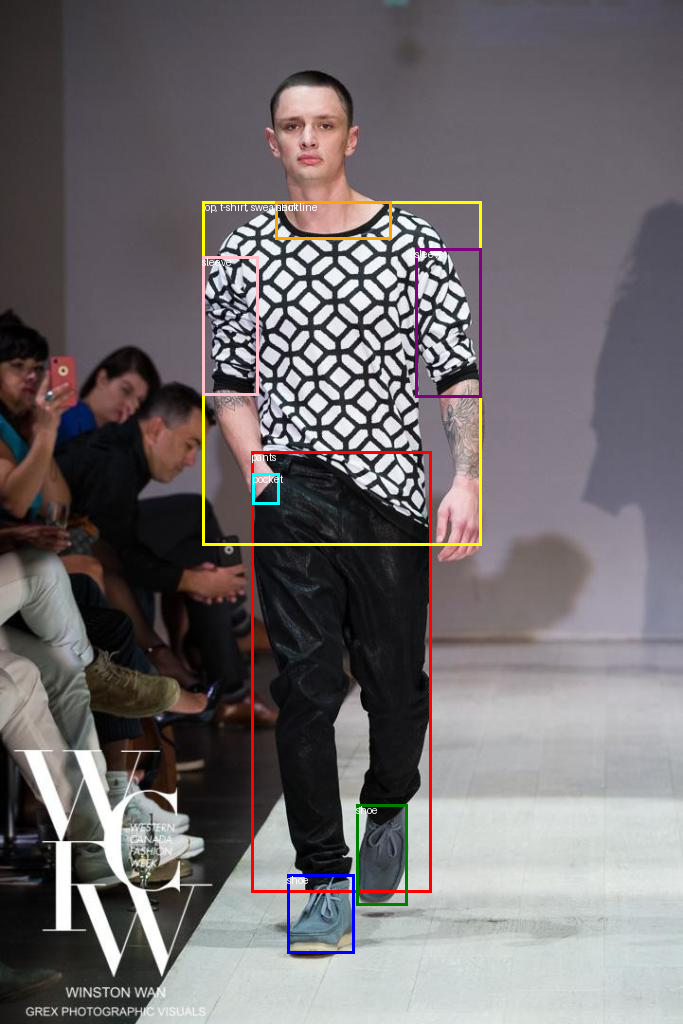

In [31]:
#idx = 10
idx = 100
ann_image = draw_image_from_idx(train_dataset, idx)
ann_image

##### Filter invalid boxes

In [20]:
def filter_invalid_bboxes(example):
    valid_bboxes = []
    valid_bbox_ids = []
    valid_categories = []
    valid_areas = []

    for i, bbox in enumerate(example['objects']['bbox']):
        x_min, y_min, x_max, y_max = bbox[:4]
        if x_min < x_max and y_min < y_max:
            valid_bboxes.append(bbox)
            valid_bbox_ids.append(example['objects']['bbox_id'][i])
            valid_categories.append(example['objects']['category'][i])
            valid_areas.append(example['objects']['area'][i])
        else:
            print(f"Image with invalid bbox: {example['image_id']} Invalid bbox detected and discarded: {bbox} - bbox_id: {example['objects']['bbox_id'][i]} - category: {example['objects']['category'][i]}")

    example['objects']['bbox'] = valid_bboxes
    example['objects']['bbox_id'] = valid_bbox_ids
    example['objects']['category'] = valid_categories
    example['objects']['area'] = valid_areas

    return example


In [21]:
train_dataset = train_dataset.map(filter_invalid_bboxes)
test_dataset = test_dataset.map(filter_invalid_bboxes)

Map:   0%|          | 0/2281 [00:00<?, ? examples/s]

Map:   0%|          | 0/115 [00:00<?, ? examples/s]

Categories like shoe, sleeves and pocktes have a higher count. Uneven distribution.

In [35]:
#idx = 10
idx = 121
np.unique(train_dataset[idx]['objects']['category'], return_counts=True)

(array([ 1,  6, 13, 23, 31, 32, 33]), array([1, 1, 1, 2, 2, 2, 1]))

#### Check for class balance/ imbalance.

In [100]:
def class_counts(dataset, id2label):
  '''
  Function calculated the distrubution of classes in the dataset.
  '''
  category_class = {}

  for elem in dataset:
    for category in elem['objects']['category']:
      if id2label[category] not in category_class:
        category_class[id2label[category]] = 1
      else:
        category_class[id2label[category]] += 1

  return category_class


def plot_class_distribution(category_class):
  '''
  Function plots the distribution of classes in the dataset.
  It takes in the count dictionary, sorts and plots the class count
  '''
  assert(isinstance(category_class,dict)), "Input should be a dictionary"

  category_class = sorted(category_class.items(),
                          key = lambda item:item[1], reverse = True)
  category_class = dict(category_class)

  classes = list(category_class.keys())
  counts = list(category_class.values())

  plt.figure(figsize=(10, 6)) #facecolor='lightblue'
  plt.bar(classes, counts, color = 'b', alpha = 0.7)
  plt.xlabel('Classes')
  plt.ylabel('Count')
  plt.title('Class Distribution')
  plt.xticks(rotation=90)

  return


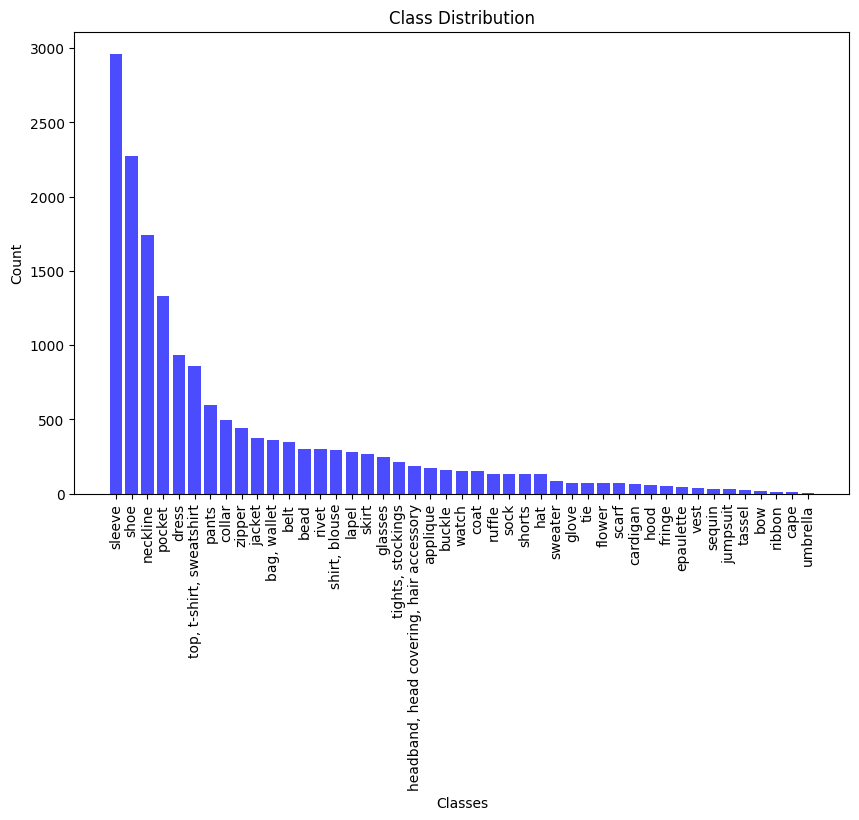

In [101]:
category_examples = class_counts(train_dataset, id2label)
plot_class_distribution(category_examples)

#### Next Steps

* Does one need Albumentations
* What are the other steps before we can start with fine stuning the final layer of the model ??

* Just all images have different height and width


In [104]:
import albumentations as A

In [108]:
# Just all images have different height and width
# for elem in train_dataset:
#   print(elem['width'], elem['height'])

In [112]:
train_transform = A.Compose(
    [

        A.LongestMaxSize(500),
        A.PadIfNeeded(500,500,border_mode=0, value=(0, 0, 0)),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.35),
        A.HueSaturationValue(p=0.5),
        A.Rotate(limit = 10, p = 0.5),
        A.RandomScale(scale_limit=0.2, p=0.6),
        A.GaussianBlur(p=0.5),
        A.GaussNoise(p=0.5)

    ],

    bbox_params = A.BboxParams (format = 'pascal_voc', label_fields=["category"]) ,

)

val_transform = A.Compose(
    [
          A.LongestMaxSize(500),
          A.PadIfNeeded(500,500,border_mode=0, value=(0, 0, 0)),

    ],
    bbox_params = A.BboxParams (format = 'pascal_voc', label_fields=["category"]) ,


)

/tmp/ipython-input-1393362006.py:5: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(500,500,border_mode=0, value=(0, 0, 0)),
/tmp/ipython-input-1393362006.py:23: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(500,500,border_mode=0, value=(0, 0, 0)),


In [113]:
train_dataset[10]

{'image_id': 35781,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=682x1024>,
 'width': 682,
 'height': 1024,
 'objects': {'bbox_id': [219416,
   219417,
   219418,
   219419,
   219420,
   219421,
   219422,
   219423,
   219424,
   219425,
   219426,
   219427,
   219428,
   219429,
   219430,
   219431,
   219432],
  'category': [1,
   31,
   33,
   31,
   6,
   35,
   32,
   42,
   32,
   42,
   32,
   32,
   32,
   23,
   23,
   32,
   32],
  'bbox': [[228.0, 317.0, 528.0, 604.0],
   [440.0, 321.0, 528.0, 409.0],
   [344.0, 318.0, 413.0, 368.0],
   [228.0, 334.0, 306.0, 410.0],
   [181.0, 576.0, 497.0, 900.0],
   [359.0, 590.0, 370.0, 619.0],
   [400.0, 610.0, 493.0, 709.0],
   [401.0, 617.0, 406.0, 622.0],
   [260.0, 640.0, 348.0, 772.0],
   [336.0, 640.0, 340.0, 645.0],
   [246.0, 674.0, 266.0, 717.0],
   [263.0, 599.0, 293.0, 642.0],
   [419.0, 576.0, 433.0, 594.0],
   [160.0, 732.0, 204.0, 808.0],
   [351.0, 877.0, 441.0, 986.0],
   [255.0, 602.0, 262.0, 618.

#### Checkout the model.

In [114]:
from transformers import AutoImageProcessor

checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

# As this is segmentation image processor you need to put in the annotations with images
#image_processor(images=images, annotations=targets, return_tensors="pt")

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


In [116]:
# Annotations for the image are stored in field 'objects' - one will need to reformat these to put them
# in the model.
train_dataset[10]['objects']

{'bbox_id': [219416,
  219417,
  219418,
  219419,
  219420,
  219421,
  219422,
  219423,
  219424,
  219425,
  219426,
  219427,
  219428,
  219429,
  219430,
  219431,
  219432],
 'category': [1,
  31,
  33,
  31,
  6,
  35,
  32,
  42,
  32,
  42,
  32,
  32,
  32,
  23,
  23,
  32,
  32],
 'bbox': [[228.0, 317.0, 528.0, 604.0],
  [440.0, 321.0, 528.0, 409.0],
  [344.0, 318.0, 413.0, 368.0],
  [228.0, 334.0, 306.0, 410.0],
  [181.0, 576.0, 497.0, 900.0],
  [359.0, 590.0, 370.0, 619.0],
  [400.0, 610.0, 493.0, 709.0],
  [401.0, 617.0, 406.0, 622.0],
  [260.0, 640.0, 348.0, 772.0],
  [336.0, 640.0, 340.0, 645.0],
  [246.0, 674.0, 266.0, 717.0],
  [263.0, 599.0, 293.0, 642.0],
  [419.0, 576.0, 433.0, 594.0],
  [160.0, 732.0, 204.0, 808.0],
  [351.0, 877.0, 441.0, 986.0],
  [255.0, 602.0, 262.0, 618.0],
  [399.0, 410.0, 435.0, 474.0]],
 'area': [46943,
  4828,
  925,
  4613,
  49049,
  103,
  5675,
  17,
  9051,
  18,
  528,
  456,
  104,
  1646,
  5428,
  80,
  1396]}

In [117]:
train_dataset[10]


{'image_id': 35781,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=682x1024>,
 'width': 682,
 'height': 1024,
 'objects': {'bbox_id': [219416,
   219417,
   219418,
   219419,
   219420,
   219421,
   219422,
   219423,
   219424,
   219425,
   219426,
   219427,
   219428,
   219429,
   219430,
   219431,
   219432],
  'category': [1,
   31,
   33,
   31,
   6,
   35,
   32,
   42,
   32,
   42,
   32,
   32,
   32,
   23,
   23,
   32,
   32],
  'bbox': [[228.0, 317.0, 528.0, 604.0],
   [440.0, 321.0, 528.0, 409.0],
   [344.0, 318.0, 413.0, 368.0],
   [228.0, 334.0, 306.0, 410.0],
   [181.0, 576.0, 497.0, 900.0],
   [359.0, 590.0, 370.0, 619.0],
   [400.0, 610.0, 493.0, 709.0],
   [401.0, 617.0, 406.0, 622.0],
   [260.0, 640.0, 348.0, 772.0],
   [336.0, 640.0, 340.0, 645.0],
   [246.0, 674.0, 266.0, 717.0],
   [263.0, 599.0, 293.0, 642.0],
   [419.0, 576.0, 433.0, 594.0],
   [160.0, 732.0, 204.0, 808.0],
   [351.0, 877.0, 441.0, 986.0],
   [255.0, 602.0, 262.0, 618.